In [4]:
import numpy as np
import scipy.stats as stats

def get_confidence_interval(sample, confidence=0.95):
    data = np.array(sample)
    n = len(data)
    if n < 2:
        raise ValueError("Размер выборки должен быть не менее 2 элементов.")
        
    mean = np.mean(data)
    sem = stats.sem(data, ddof=1) 
    
    # Считаем через t-распределение (математически строго для любых n)
    interval = stats.t.interval(confidence, df=n-1, loc=mean, scale=sem)
    return interval

# Задаем границы усечения стандартного нормального распределения
lower, upper = -1, 1
mu, sigma = 0, 0.35 # mu - центр (mean), sigma - разброс данных

# Создаем объект усеченного распределения
trunc_dist = stats.truncnorm((lower - mu) / sigma, (upper - mu) / sigma, loc=mu, scale=sigma)

# Эксперимент 1: Большая выборка
sample_1000 = trunc_dist.rvs(1000, random_state=41)
b1_1000, b2_1000 = get_confidence_interval(sample_1000)
print(f'Доверительный интервал (n=1000): от {b1_1000:.4f} до {b2_1000:.4f}')

# Эксперимент 2: Маленькая выборка
sample_10 = trunc_dist.rvs(10, random_state=41)
b1_10, b2_10 = get_confidence_interval(sample_10)
print(f'Доверительный интервал (n=10):   от {b1_10:.4f} до {b2_10:.4f}')

Доверительный интервал (n=1000): от -0.0278 до 0.0141
Доверительный интервал (n=10):   от -0.3849 до 0.1222


Чем больше чисел - тем меньше границы доверительного интервала (алгоритм становится более уверенным в том, где находится истинное среднее)

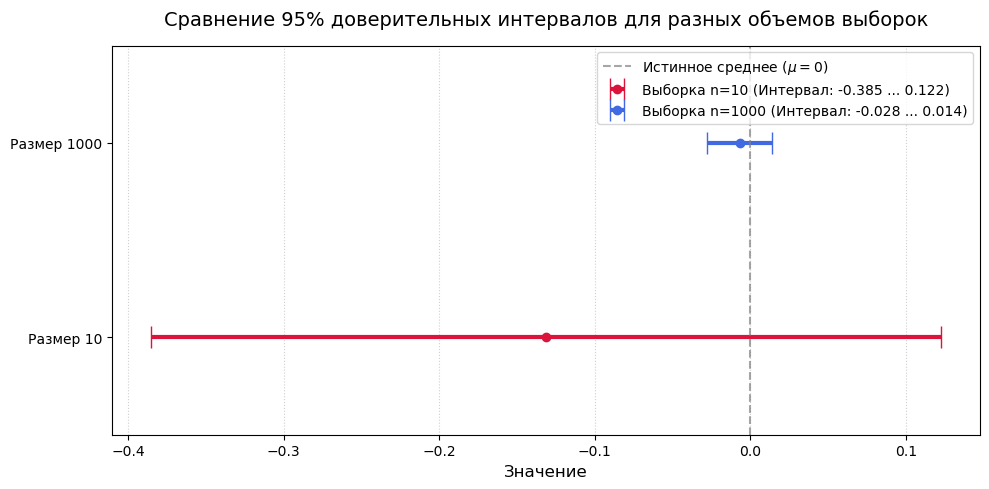

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Вычисляем средние значения для графиков
mean_1000 = np.mean(sample_1000)
mean_10 = np.mean(sample_10)

# Явная инициализация объектов фигуры и осей (ООП-подход Matplotlib)
fig, ax = plt.subplots(figsize=(10, 5))

# Отрисовка интервала для n=10 через методы объекта ax
ax.errorbar(
    x=mean_10, 
    y=1, 
    xerr=[[mean_10 - b1_10], [b2_10 - mean_10]], 
    fmt='o', 
    color='crimson', 
    elinewidth=3, 
    capsize=8, 
    label=f'Выборка n=10 (Интервал: {b1_10:.3f} ... {b2_10:.3f})'
)

# Отрисовка интервала для n=1000 через методы объекта ax
ax.errorbar(
    x=mean_1000, 
    y=2, 
    xerr=[[mean_1000 - b1_1000], [b2_1000 - mean_1000]], 
    fmt='o', 
    color='royalblue', 
    elinewidth=3, 
    capsize=8, 
    label=f'Выборка n=1000 (Интервал: {b1_1000:.3f} ... {b2_1000:.3f})'
)

# Линия истинного среднего значения генеральной совокупности (mu = 0)
ax.axvline(x=mu, color='gray', linestyle='--', alpha=0.7, label=f'Истинное среднее ($\mu = {mu}$)')

# Настройка осей и оформления через методы объекта ax (set_*)
ax.set_yticks([1, 2])
ax.set_yticklabels(['Размер 10', 'Размер 1000'])
ax.set_ylim(0.5, 2.5)
ax.set_xlabel('Значение', fontsize=12)
ax.set_title('Сравнение 95% доверительных интервалов для разных объемов выборок', fontsize=14, pad=15)

# Сетка, легенда и отображение
ax.grid(axis='x', linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

fig.tight_layout()
plt.show()